Case Study 2

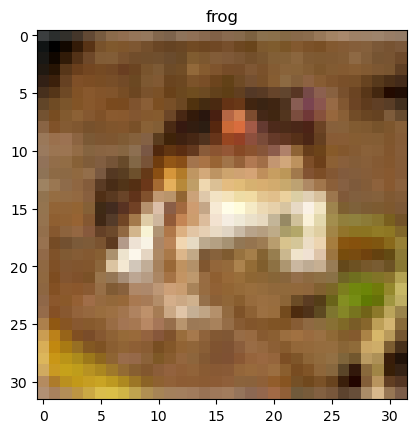

c:\Users\HARSH VARDHAN SHUKLA\anaconda3\envs\ai\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.4593 - loss: 1.4842 - val_accuracy: 0.5509 - val_loss: 1.2475
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6037 - loss: 1.1227 - val_accuracy: 0.6044 - val_loss: 1.1398
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6616 - loss: 0.9649 - val_accuracy: 0.6618 - val_loss: 0.9478
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6963 - loss: 0.8665 - val_accuracy: 0.6895 - val_loss: 0.9054
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7229 - loss: 0.7933 - val_accuracy: 0.6874 - val_loss: 0.8935
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7449 - loss: 0.7307 - val_accuracy: 0.7060 - val_loss: 0.8578
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7611 - loss: 0.6810 - val_accuracy: 0.6982 - val_loss: 0.8914
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7779 - loss: 0

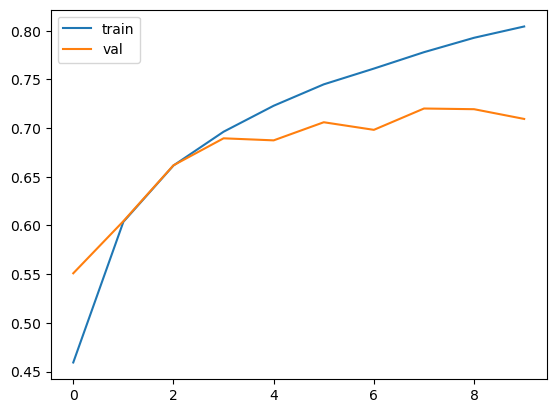

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predicted: cat
Actual: cat


In [1]:

import tensorflow as tf 
from tensorflow.keras import datasets, layers, models 
import matplotlib.pyplot as plt 
import numpy as np 

(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data() 

X_train = X_train / 255.0 
X_test = X_test / 255.0 

class_names = ['airplane','automobile','bird','cat','deer', 
'dog','frog','horse','ship','truck'] 

plt.imshow(X_train[0]) 
plt.title(class_names[y_train[0][0]]) 
plt.show() 

model = models.Sequential([ 
layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)), 
layers.MaxPooling2D((2,2)), 
layers.Conv2D(64, (3,3), activation='relu'), 
layers.MaxPooling2D((2,2)), 
 
 
 
    layers.Conv2D(64, (3,3), activation='relu'), 
 
    layers.Flatten(), 
    layers.Dense(64, activation='relu'), 
    layers.Dense(10, activation='softmax') 
]) 
 

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy']) 
 

history = model.fit(X_train, y_train, epochs=10, 
                    validation_data=(X_test, y_test)) 
 

test_loss, test_acc = model.evaluate(X_test, y_test) 
print("Test Accuracy:", test_acc) 
 

plt.plot(history.history['accuracy'], label='train') 
plt.plot(history.history['val_accuracy'], label='val') 
plt.legend() 
plt.show() 
 

predictions = model.predict(X_test) 
print("Predicted:", class_names[np.argmax(predictions[0])]) 
print("Actual:", class_names[y_test[0][0]]) 
